In [3]:
!pip install wordcloud matplotlib

Note: you may need to restart the kernel to use updated packages.


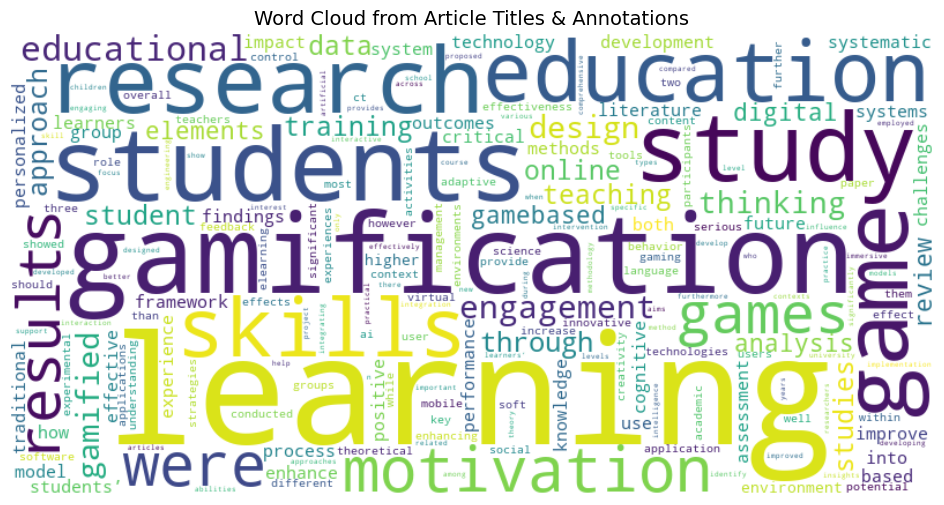

In [5]:
# Import necessary libraries
import re
import string
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# NOTE: AbstractDataset.docx is stored as plain UTF-8 text (not a real binary
# .docx / OOXML file), so it is read directly as text rather than parsed
# with python-docx. If this file is ever replaced with a genuine Word
# document, switch back to python-docx's Document() reader instead.
def extract_text_from_abstract_file(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return f.read()

# Specify the path to the abstracts file (must be present in the repository root)
file_path = "AbstractDataset.docx"

# Extract text from the file
text = extract_text_from_abstract_file(file_path)

# Define a list of stopwords to remove common words
custom_stopwords = set([
    "the", "and", "to", "of", "in", "a", "for", "on", "with", "as", "by", "this",
    "is", "was", "an", "are", "that", "from", "it", "we", "at", "be", "have",
    "not", "which", "has", "its", "can", "also", "been", "their", "but", "or",
    "they", "such", "these", "more", "all", "some", "if", "other", "one", "may",
    "our", "between", "using", "used", "about"
])

# Clean text and remove stopwords
words = text.lower().translate(str.maketrans("", "", string.punctuation)).split()
filtered_words = [word for word in words if word not in custom_stopwords]

# Perform word frequency analysis
word_freq = Counter(filtered_words)

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate_from_frequencies(word_freq)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud from Article Titles & Annotations", fontsize=14)
plt.show()